<a href="https://www.kaggle.com/code/navneet0094/ckplus-jafee-hog-combined?scriptVersionId=314101505" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S071_001_00000012.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S082_001_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S116_001_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S097_001_00000020.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S085_003_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S127_001_00000015.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S085_003_00000011.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S107_001_00000008.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S138_004_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S068_003_00000013.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S126_004_00000010.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surprise/S068_003_00000014.png
/kaggle/input/datasets/shawon10/ckplus/ck/CK+48/surp

In [12]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [14]:
import os, cv2, numpy as np

ck_data = []
ck_labels = []

ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

emotion_names = sorted(os.listdir(ck_path))  # keep consistent order

for label, emotion in enumerate(emotion_names):
    emotion_path = os.path.join(ck_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
            
        img = cv2.resize(img, (48,48))

        ck_data.append(img)
        ck_labels.append(label)

ck_data = np.array(ck_data)
ck_labels = np.array(ck_labels)

print("CK+:", ck_data.shape)
print("Labels:", np.unique(ck_labels))

CK+: (981, 48, 48)
Labels: [0 1 2 3 4 5 6]


In [15]:
from PIL import Image

jaffe_data = []
jaffe_labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

jaffe_path = "/kaggle/input/datasets/navneet0094/jafee-da/jaffe"

for img_name in os.listdir(jaffe_path):
    img_path = os.path.join(jaffe_path, img_name)

    try:
        img = Image.open(img_path).convert('L')
        img = img.resize((48,48))
        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        jaffe_data.append(img)
        jaffe_labels.append(label)

    except:
        continue

jaffe_data = np.array(jaffe_data)
jaffe_labels = np.array(jaffe_labels)

print("JAFFE:", jaffe_data.shape)

JAFFE: (213, 48, 48)


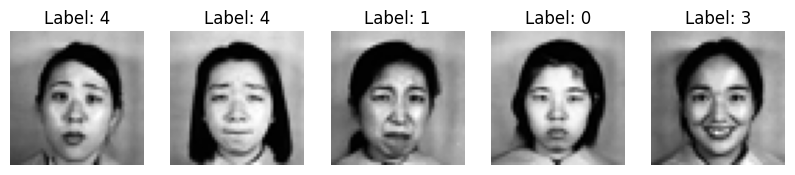

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(jaffe_data[i], cmap='gray')
    plt.title(f"Label: {jaffe_labels[i]}")
    plt.axis('off')

plt.show()

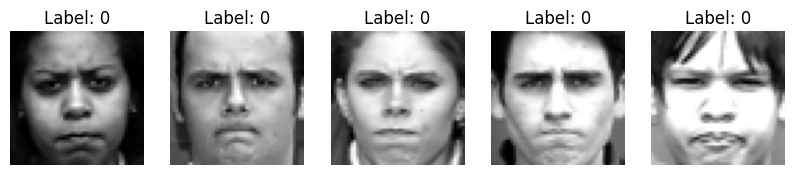

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(ck_data[i], cmap='gray')
    plt.title(f"Label: {ck_labels[i]}")
    plt.axis('off')

plt.show()

In [19]:
from skimage.feature import hog

def extract_hog(images):
    return np.array([
        hog(img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2))
        for img in images
    ])

X_ck_hog = extract_hog(ck_data)
X_jaffe_hog = extract_hog(jaffe_data)

print("CK+ HOG:", X_ck_hog.shape)
print("JAFFE HOG:", X_jaffe_hog.shape)

CK+ HOG: (981, 900)
JAFFE HOG: (213, 900)


In [20]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
model = LinearSVC(max_iter=5000)
# TRAIN
model.fit(X_ck_hog, ck_labels)
# TEST
y_pred = model.predict(X_jaffe_hog)

accuracy = accuracy_score(jaffe_labels, y_pred)

print("CK+ → JAFFE Accuracy:", accuracy)

CK+ → JAFFE Accuracy: 0.11267605633802817


In [22]:
emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']

print(classification_report(jaffe_labels, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        30
     disgust       0.00      0.00      0.00        29
        fear       0.00      0.00      0.00        32
       happy       0.07      0.03      0.04        31
     sadness       0.00      0.00      0.00        31
    surprise       0.00      0.00      0.00        30
     neutral       0.13      0.77      0.22        30

    accuracy                           0.11       213
   macro avg       0.03      0.11      0.04       213
weighted avg       0.03      0.11      0.04       213



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


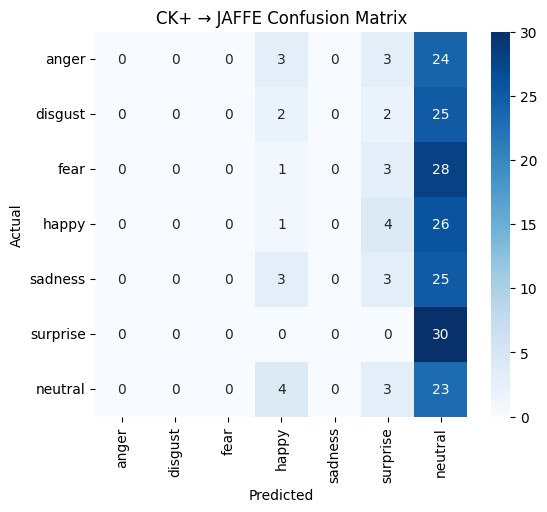

In [23]:
cm = confusion_matrix(jaffe_labels, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("CK+ → JAFFE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Now lets make ckplus as test data and jafee as training data 

In [24]:
from sklearn.svm import LinearSVC

model = LinearSVC(max_iter=5000)

# TRAIN on JAFFE
model.fit(X_jaffe_hog, jaffe_labels)

LinearSVC(max_iter=5000)

In [25]:
from sklearn.metrics import accuracy_score

# TEST on CK+
y_pred_ck = model.predict(X_ck_hog)

acc = accuracy_score(ck_labels, y_pred_ck)

print("JAFFE → CK+ Accuracy:", acc)

JAFFE → CK+ Accuracy: 0.12538226299694188


In [26]:
from sklearn.metrics import classification_report

emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']

print(classification_report(ck_labels, y_pred_ck, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       135
     disgust       0.03      0.09      0.04        54
        fear       0.15      0.66      0.25       177
       happy       0.00      0.00      0.00        75
     sadness       0.09      0.00      0.01       207
    surprise       0.00      0.00      0.00        84
     neutral       0.00      0.00      0.00       249

    accuracy                           0.13       981
   macro avg       0.04      0.11      0.04       981
weighted avg       0.05      0.13      0.05       981



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


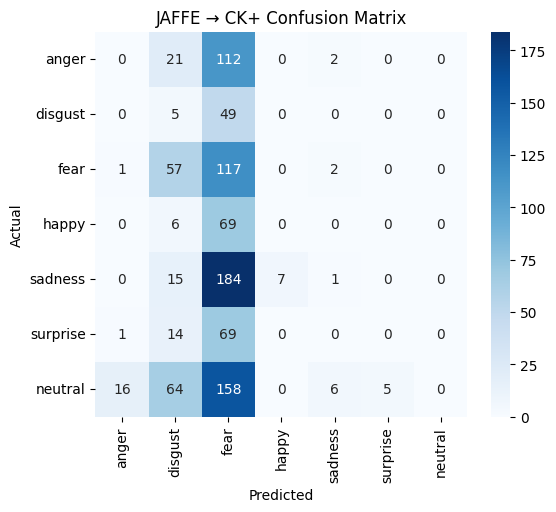

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(ck_labels, y_pred_ck)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("JAFFE → CK+ Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

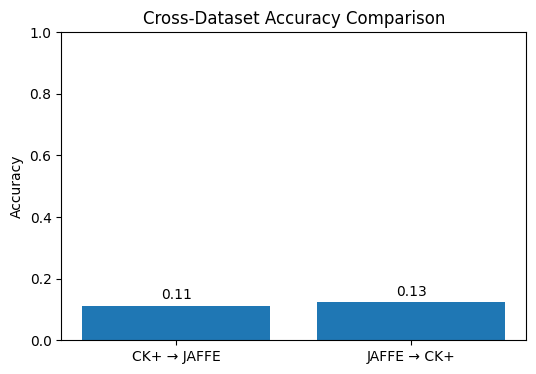

In [28]:
import matplotlib.pyplot as plt

methods = ['CK+ → JAFFE', 'JAFFE → CK+']
accuracies = [accuracy, acc]

plt.figure(figsize=(6,4))
bars = plt.bar(methods, accuracies)

plt.ylim(0,1)
plt.title("Cross-Dataset Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.2f}",
             ha='center')

plt.show()

## Now let's combine both and then check acc

In [29]:
import numpy as np

# Combining features
X_combined = np.concatenate([X_ck_hog, X_jaffe_hog], axis=0)

# Combining labels
y_combined = np.concatenate([ck_labels, jaffe_labels], axis=0)

print("Combined shape:", X_combined.shape)

Combined shape: (1194, 900)


In [30]:
from sklearn.model_selection import train_test_split

# Spliting JAFFE into train + test
X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(
    X_jaffe_hog,
    jaffe_labels,
    test_size=0.8,   # 80% for testing
    random_state=42,
    stratify=jaffe_labels
)

In [31]:
# Combine CK+ with part of JAFFE
X_train_final = np.concatenate([X_ck_hog, X_j_train], axis=0)
y_train_final = np.concatenate([ck_labels, y_j_train], axis=0)

print("Train shape:", X_train_final.shape)
print("Test shape:", X_j_test.shape)

Train shape: (1023, 900)
Test shape: (171, 900)


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(max_iter=5000))
])

model.fit(X_train_final, y_train_final)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', LinearSVC(max_iter=5000))])

In [33]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_j_test)
acc_combined = accuracy_score(y_j_test, y_pred)

print("Combined → JAFFE Accuracy:", acc_combined)

Combined → JAFFE Accuracy: 0.29239766081871343


In [34]:
from sklearn.metrics import classification_report

emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']

print(classification_report(y_j_test, y_pred, target_names=emotion_names))


              precision    recall  f1-score   support

       anger       0.33      0.33      0.33        24
     disgust       0.27      0.30      0.29        23
        fear       0.26      0.19      0.22        26
       happy       0.33      0.36      0.35        25
     sadness       0.14      0.16      0.15        25
    surprise       0.35      0.38      0.36        24
     neutral       0.38      0.33      0.36        24

    accuracy                           0.29       171
   macro avg       0.30      0.29      0.29       171
weighted avg       0.29      0.29      0.29       171



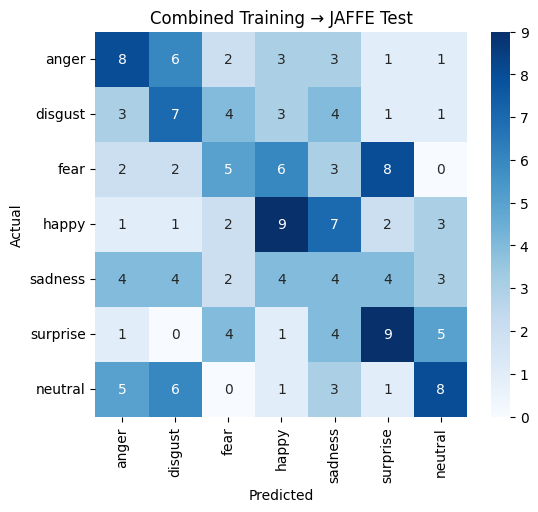

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_j_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("Combined Training → JAFFE Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

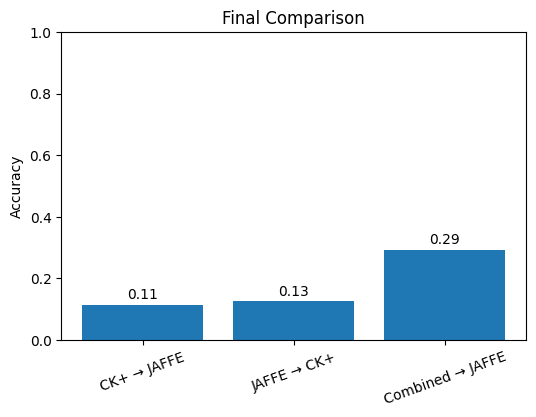

In [36]:
methods = ['CK+ → JAFFE', 'JAFFE → CK+', 'Combined → JAFFE']
accuracies = [accuracy, acc, acc_combined]   

plt.figure(figsize=(6,4))
bars = plt.bar(methods, accuracies)

plt.ylim(0,1)
plt.title("Final Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.2f}",
             ha='center')

plt.xticks(rotation=20)
plt.show()

In [37]:

percentages = [0.1, 0.2, 0.3]
results = []

for p in percentages:
    
    # Spliting JAFFE
    X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(
        X_jaffe_hog,
        jaffe_labels,
        test_size=1-p,
        random_state=42,
        stratify=jaffe_labels
    )
    
    # Combining with CK+
    X_train = np.concatenate([X_ck_hog, X_j_train])
    y_train = np.concatenate([ck_labels, y_j_train])
    
    # Model
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(max_iter=5000))
    ])
    
    model.fit(X_train, y_train)
    
    # Test on unseen JAFFE
    y_pred = model.predict(X_j_test)
    
    acc = accuracy_score(y_j_test, y_pred)
    results.append(acc)
    
    print(f"{int(p*100)}% JAFFE → Accuracy:", acc)

10% JAFFE → Accuracy: 0.16145833333333334
20% JAFFE → Accuracy: 0.29239766081871343
30% JAFFE → Accuracy: 0.34


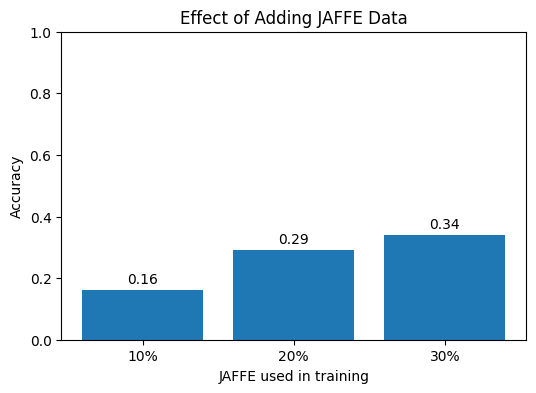

In [38]:
import matplotlib.pyplot as plt

labels = ['10%', '20%', '30%','50']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, results)

plt.ylim(0,1)
plt.title("Effect of Adding JAFFE Data")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.2f}",
             ha='center')

plt.show()